# Importing Laibraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from tensorflow.keras.callbacks import EarlyStopping
from google.colab import drive

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


# Importing DataSet

In [3]:
df=pd.read_csv('/content/drive/MyDrive/python-Saylani/healthcare-dataset-stroke-data.csv')
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


# Data Cleaning & Preprocessing

### 1. Shape Of The Data

In [4]:
df.shape

(5110, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


### 2. Remove Null Values

In [6]:
df.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


In [7]:
df.dropna(inplace=True)

In [8]:
df.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0


In [9]:
df.duplicated().sum()

np.int64(0)

Delete Id Column(Not Relaible For Modeling)

In [10]:
del df['id']
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1


In [11]:
df.reset_index(inplace=True,drop=True)
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
2,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
3,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
4,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1


# Exploratory Data Analysis(EDA)

### 1. Uniqueness Of the Columns

In [12]:
df.gender.unique()

array(['Male', 'Female', 'Other'], dtype=object)

In [13]:
df.hypertension.unique()

array([0, 1])

In [14]:
df.age.unique()

array([6.70e+01, 8.00e+01, 4.90e+01, 7.90e+01, 8.10e+01, 7.40e+01,
       6.90e+01, 7.80e+01, 6.10e+01, 5.40e+01, 5.00e+01, 6.40e+01,
       7.50e+01, 6.00e+01, 7.10e+01, 5.20e+01, 8.20e+01, 6.50e+01,
       5.70e+01, 4.20e+01, 4.80e+01, 7.20e+01, 5.80e+01, 7.60e+01,
       3.90e+01, 7.70e+01, 6.30e+01, 7.30e+01, 5.60e+01, 4.50e+01,
       7.00e+01, 5.90e+01, 6.60e+01, 4.30e+01, 6.80e+01, 4.70e+01,
       5.30e+01, 3.80e+01, 5.50e+01, 4.60e+01, 3.20e+01, 5.10e+01,
       1.40e+01, 3.00e+00, 8.00e+00, 3.70e+01, 4.00e+01, 3.50e+01,
       2.00e+01, 4.40e+01, 2.50e+01, 2.70e+01, 2.30e+01, 1.70e+01,
       1.30e+01, 4.00e+00, 1.60e+01, 2.20e+01, 3.00e+01, 2.90e+01,
       1.10e+01, 2.10e+01, 1.80e+01, 3.30e+01, 2.40e+01, 3.60e+01,
       6.40e-01, 3.40e+01, 4.10e+01, 8.80e-01, 5.00e+00, 2.60e+01,
       3.10e+01, 7.00e+00, 1.20e+01, 6.20e+01, 2.00e+00, 9.00e+00,
       1.50e+01, 2.80e+01, 1.00e+01, 1.80e+00, 3.20e-01, 1.08e+00,
       1.90e+01, 6.00e+00, 1.16e+00, 1.00e+00, 1.40e+00, 1.72e

In [15]:
df.heart_disease.unique()

array([1, 0])

In [16]:
df.ever_married.unique()

array(['Yes', 'No'], dtype=object)

In [17]:
df.work_type.unique()

array(['Private', 'Self-employed', 'Govt_job', 'children', 'Never_worked'],
      dtype=object)

In [18]:
df.Residence_type.unique()

array(['Urban', 'Rural'], dtype=object)

In [19]:
df.avg_glucose_level.unique()

array([228.69, 105.92, 171.23, ...,  82.99, 166.29,  85.28])

In [20]:
df.bmi.unique()

array([36.6, 32.5, 34.4, 24. , 29. , 27.4, 22.8, 24.2, 29.7, 36.8, 27.3,
       28.2, 30.9, 37.5, 25.8, 37.8, 22.4, 48.9, 26.6, 27.2, 23.5, 28.3,
       44.2, 25.4, 22.2, 30.5, 26.5, 33.7, 23.1, 32. , 29.9, 23.9, 28.5,
       26.4, 20.2, 33.6, 38.6, 39.2, 27.7, 31.4, 36.5, 33.2, 32.8, 40.4,
       25.3, 30.2, 47.5, 20.3, 30. , 28.9, 28.1, 31.1, 21.7, 27. , 24.1,
       45.9, 44.1, 22.9, 29.1, 32.3, 41.1, 25.6, 29.8, 26.3, 26.2, 29.4,
       24.4, 28. , 28.8, 34.6, 19.4, 30.3, 41.5, 22.6, 56.6, 27.1, 31.3,
       31. , 31.7, 35.8, 28.4, 20.1, 26.7, 38.7, 34.9, 25. , 23.8, 21.8,
       27.5, 24.6, 32.9, 26.1, 31.9, 34.1, 36.9, 37.3, 45.7, 34.2, 23.6,
       22.3, 37.1, 45. , 25.5, 30.8, 37.4, 34.5, 27.9, 29.5, 46. , 42.5,
       35.5, 26.9, 45.5, 31.5, 33. , 23.4, 30.7, 20.5, 21.5, 40. , 28.6,
       42.2, 29.6, 35.4, 16.9, 26.8, 39.3, 32.6, 35.9, 21.2, 42.4, 40.5,
       36.7, 29.3, 19.6, 18. , 17.6, 19.1, 50.1, 17.7, 54.6, 35. , 22. ,
       39.4, 19.7, 22.5, 25.2, 41.8, 60.9, 23.7, 24

In [21]:
df.smoking_status.unique()

array(['formerly smoked', 'never smoked', 'smokes', 'Unknown'],
      dtype=object)

In [22]:
df.stroke.unique()

array([1, 0])

In [23]:
df.gender.value_counts()

,count
gender,
Female,2897
Male,2011
Other,1


Remove 1 Value of Other in "gender" Column

In [24]:
df=df[df['gender']!='Other']

In [25]:
df.gender.value_counts()

,count
gender,
Female,2897
Male,2011


<Axes: xlabel='gender', ylabel='count'>

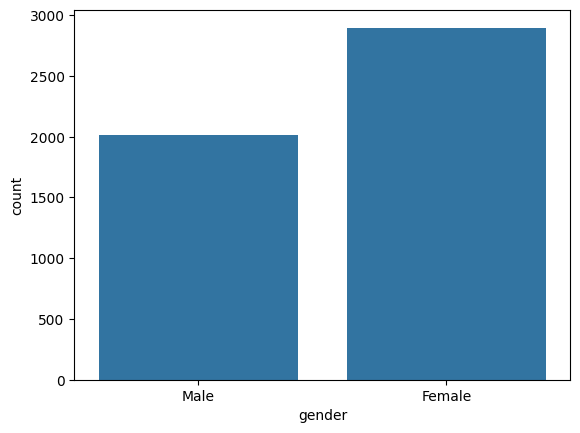

In [26]:
sns.countplot(data=df,x='gender')

In [27]:
np.mean(df['age'])

np.float64(42.86881010594947)

In [28]:
df.ever_married.value_counts()

,count
ever_married,
Yes,3204
No,1704


<Axes: xlabel='ever_married', ylabel='count'>

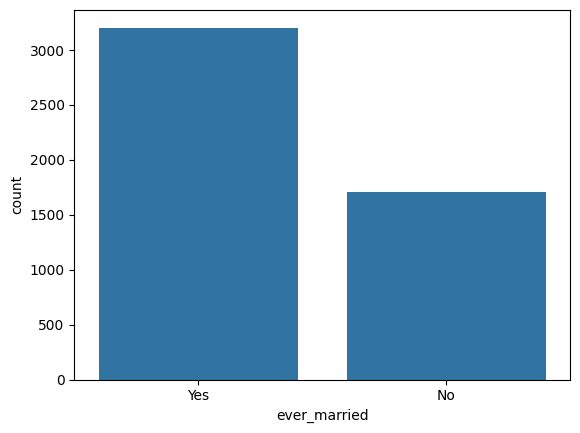

In [29]:
sns.countplot(data=df,x='ever_married')

In [30]:
df.work_type.value_counts()

,count
work_type,
Private,2810
Self-employed,775
children,671
Govt_job,630
Never_worked,22


<Axes: xlabel='work_type', ylabel='count'>

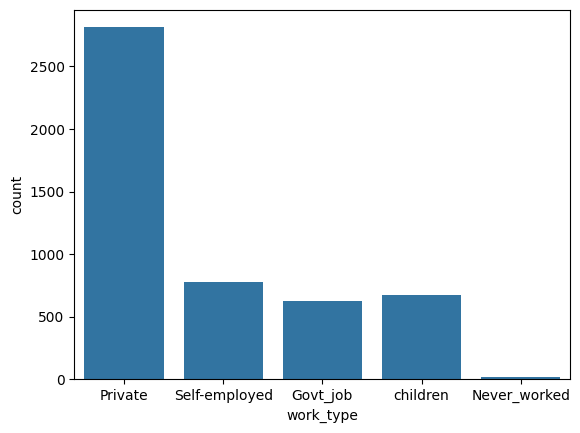

In [31]:
sns.countplot(data=df,x='work_type')

In [32]:
df.Residence_type.value_counts()

,count
Residence_type,
Urban,2490
Rural,2418


<Axes: xlabel='Residence_type', ylabel='count'>

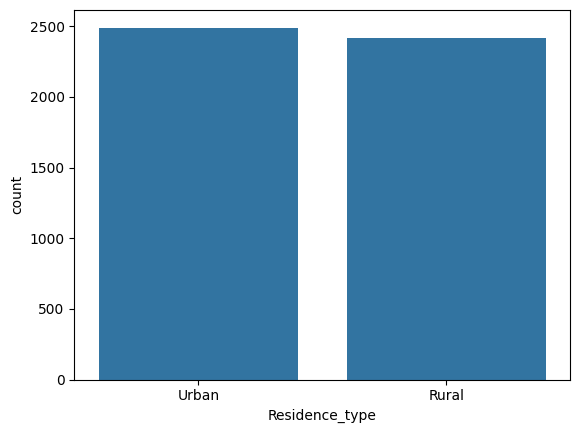

In [33]:
sns.countplot(data=df,x='Residence_type')

In [34]:
df.smoking_status.value_counts()

,count
smoking_status,
never smoked,1852
Unknown,1483
formerly smoked,836
smokes,737


<Axes: xlabel='smoking_status', ylabel='count'>

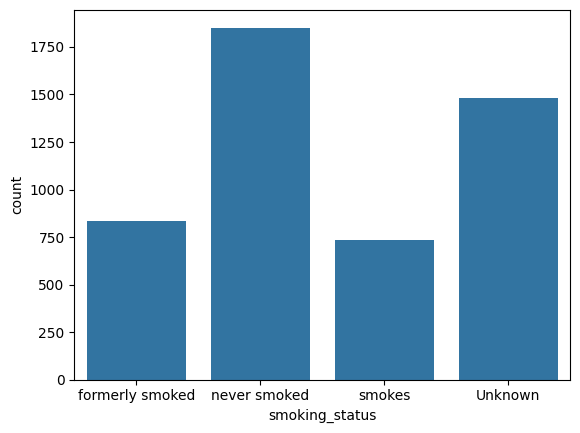

In [35]:
sns.countplot(data=df,x='smoking_status')

In [36]:
df.stroke.value_counts()

,count
stroke,
0,4699
1,209


<Axes: xlabel='stroke', ylabel='count'>

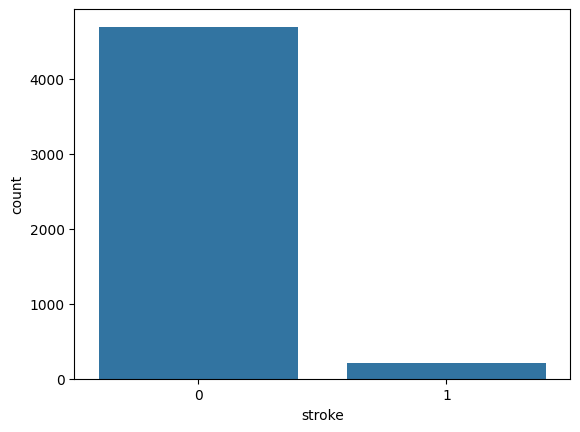

In [37]:
sns.countplot(data=df,x='stroke')

In [38]:
df.heart_disease.value_counts()

,count
heart_disease,
0,4665
1,243


<Axes: xlabel='heart_disease', ylabel='count'>

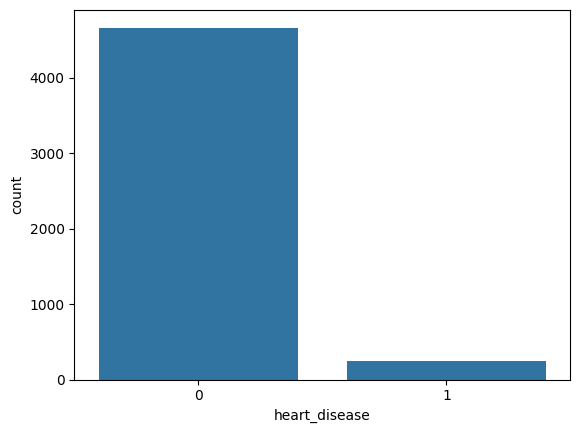

In [39]:
sns.countplot(data=df,x='heart_disease')

In [40]:
df.hypertension.value_counts()

,count
hypertension,
0,4457
1,451


<Axes: xlabel='hypertension', ylabel='count'>

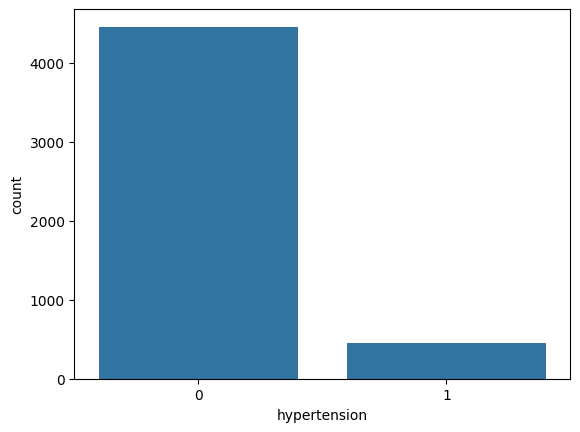

In [41]:
sns.countplot(data=df,x='hypertension')

<Axes: xlabel='age', ylabel='Count'>

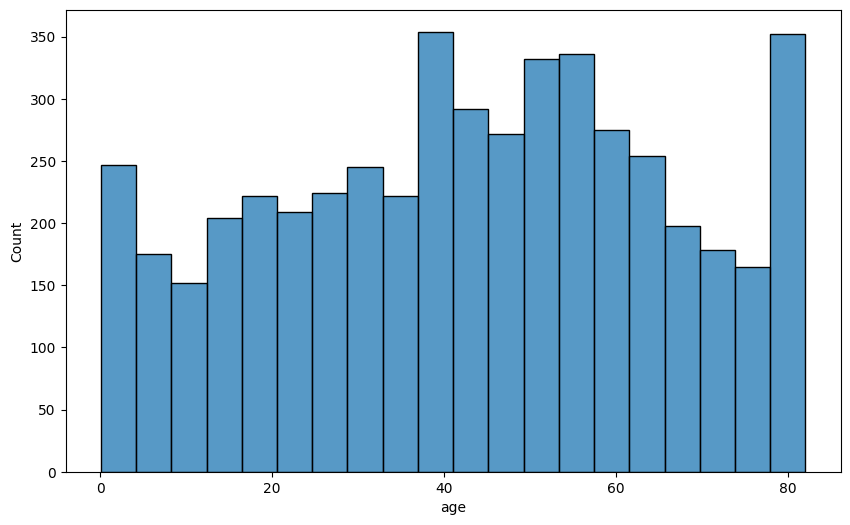

In [42]:
plt.figure(figsize=(10,6))
sns.histplot(data=df,x='age')

<Axes: xlabel='avg_glucose_level', ylabel='Count'>

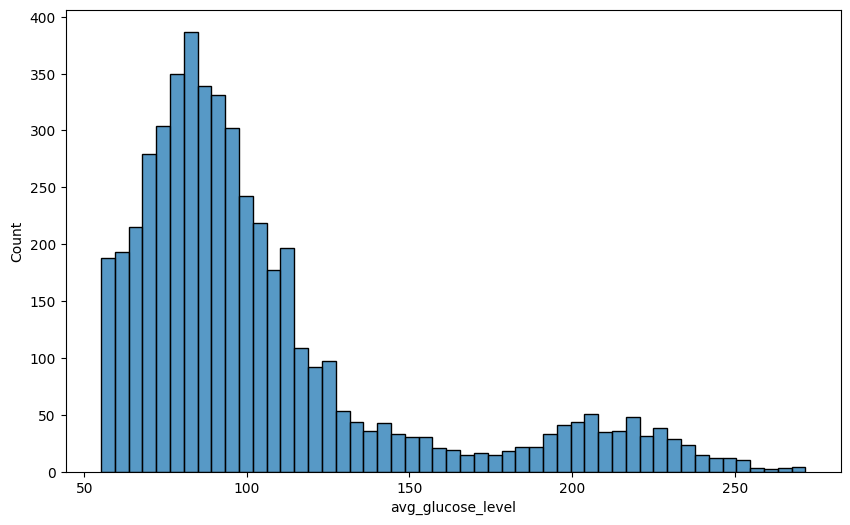

In [43]:
plt.figure(figsize=(10,6))
sns.histplot(data=df,x='avg_glucose_level')

<Axes: xlabel='bmi', ylabel='Count'>

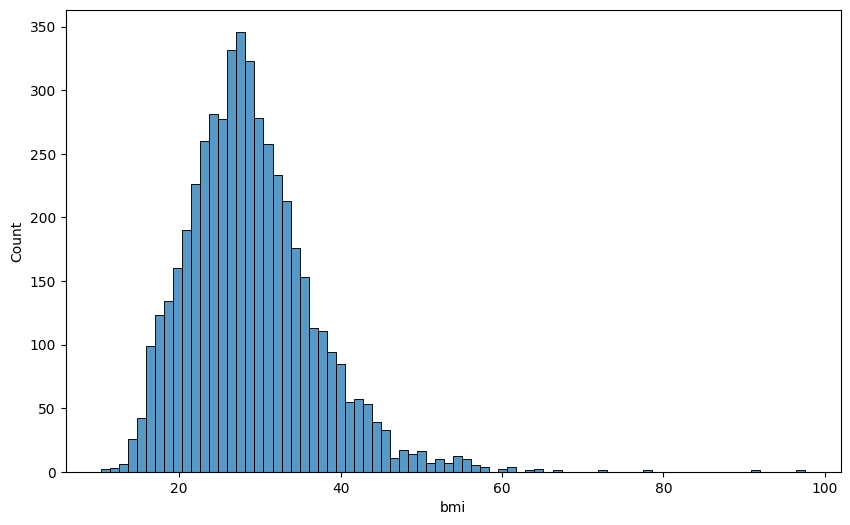

In [44]:
plt.figure(figsize=(10,6))
sns.histplot(data=df,x='bmi')

In [45]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
2,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
3,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
4,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1


# Data Encoding

In [46]:
from sklearn.preprocessing import OneHotEncoder

In [47]:
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

# Initialize OneHotEncoder with sparse_output=False
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit and transform the categorical columns
encoded_features = ohe.fit_transform(df[categorical_cols])



In [48]:
encoded_features

array([[0., 1., 0., ..., 1., 0., 0.],
       [0., 1., 0., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 0., 1.],
       ...,
       [1., 0., 0., ..., 0., 1., 0.],
       [0., 1., 0., ..., 1., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.]])

In [49]:
ohe.get_feature_names_out()

array(['gender_Female', 'gender_Male', 'ever_married_No',
       'ever_married_Yes', 'work_type_Govt_job', 'work_type_Never_worked',
       'work_type_Private', 'work_type_Self-employed',
       'work_type_children', 'Residence_type_Rural',
       'Residence_type_Urban', 'smoking_status_Unknown',
       'smoking_status_formerly smoked', 'smoking_status_never smoked',
       'smoking_status_smokes'], dtype=object)

In [50]:
# Create a DataFrame from the encoded features with their column names
encoded_df = pd.DataFrame(encoded_features, columns=ohe.get_feature_names_out(categorical_cols), index=df.index)
encoded_df.head()

,gender_Female,gender_Male,ever_married_No,ever_married_Yes,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Rural,Residence_type_Urban,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [51]:
# Drop the original categorical columns from the main DataFrame
df_processed = df.drop(columns=categorical_cols)
df_processed.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
0,67.0,0,1,228.69,36.6,1
1,80.0,0,1,105.92,32.5,1
2,49.0,0,0,171.23,34.4,1
3,79.0,1,0,174.12,24.0,1
4,81.0,0,0,186.21,29.0,1


In [52]:
# Drop the original categorical columns from the main DataFrame
df_processed = df.drop(columns=categorical_cols)
df_processed.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
0,67.0,0,1,228.69,36.6,1
1,80.0,0,1,105.92,32.5,1
2,49.0,0,0,171.23,34.4,1
3,79.0,1,0,174.12,24.0,1
4,81.0,0,0,186.21,29.0,1


In [53]:
# Concatenate the processed DataFrame with the new one-hot encoded DataFrame
df = pd.concat([df_processed, encoded_df], axis=1)
df.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Female,gender_Male,ever_married_No,ever_married_Yes,...,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Rural,Residence_type_Urban,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,228.69,36.6,1,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,80.0,0,1,105.92,32.5,1,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,49.0,0,0,171.23,34.4,1,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,79.0,1,0,174.12,24.0,1,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,81.0,0,0,186.21,29.0,1,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


# Data Seperation

In [54]:
x=df.drop('stroke',axis=1)
y=df.stroke

In [55]:
x.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,gender_Female,gender_Male,ever_married_No,ever_married_Yes,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Rural,Residence_type_Urban,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,228.69,36.6,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,80.0,0,1,105.92,32.5,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,49.0,0,0,171.23,34.4,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,79.0,1,0,174.12,24.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,81.0,0,0,186.21,29.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [56]:
x.shape

(4908, 20)

In [57]:
y.shape

(4908,)

In [58]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [59]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3926 entries, 3358 to 196
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             3926 non-null   float64
 1   hypertension                    3926 non-null   int64  
 2   heart_disease                   3926 non-null   int64  
 3   avg_glucose_level               3926 non-null   float64
 4   bmi                             3926 non-null   float64
 5   gender_Female                   3926 non-null   float64
 6   gender_Male                     3926 non-null   float64
 7   ever_married_No                 3926 non-null   float64
 8   ever_married_Yes                3926 non-null   float64
 9   work_type_Govt_job              3926 non-null   float64
 10  work_type_Never_worked          3926 non-null   float64
 11  work_type_Private               3926 non-null   float64
 12  work_type_Self-employed         3926 

In [60]:
y_train.info()

<class 'pandas.core.series.Series'>
Index: 3926 entries, 3358 to 196
Series name: stroke
Non-Null Count  Dtype
--------------  -----
3926 non-null   int64
dtypes: int64(1)
memory usage: 61.3 KB


# Data Modeling With ANN

In [69]:
from tensorflow.keras import regularizers

In [70]:
model=tf.keras.Sequential([

    tf.keras.layers.InputLayer(input_shape=x_train.shape[1:]),

    tf.keras.layers.Dense(16,activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    tf.keras.layers.Dense(8,activation='relu', kernel_regularizer=regularizers.l2(0.01)),



    tf.keras.layers.Dense(1,activation='sigmoid')
])

In [71]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 481 (1.88 KB)

 Trainable params: 481 (1.88 KB)

 Non-trainable params: 0 (0.00 B)

In [72]:
model.compile(optimizer='Adam',loss='binary_crossentropy',metrics=['accuracy'])

In [73]:
early_stopping=EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)

In [74]:
history=model.fit(x_train,y_train,epochs=15,verbose=1,validation_split=0.2,callbacks=[early_stopping])

Epoch 1/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8044 - loss: 0.6821 - val_accuracy: 0.9618 - val_loss: 0.3403
Epoch 2/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9550 - loss: 0.3340 - val_accuracy: 0.9618 - val_loss: 0.2718
Epoch 3/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9611 - loss: 0.2501 - val_accuracy: 0.9618 - val_loss: 0.2385
Epoch 4/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9566 - loss: 0.2451 - val_accuracy: 0.9618 - val_loss: 0.2258
Epoch 5/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9499 - loss: 0.2395 - val_accuracy: 0.9618 - val_loss: 0.2218
Epoch 6/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9640 - loss: 0.1960 - val_accuracy: 0.9618 - val_loss: 0.2258
Epoch 7/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9625 - loss: 0.1931 - val_accuracy: 0.9631 - val_loss: 0.2131
Epoch 8/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9550 - loss: 0.2105 - val_accuracy: 0.9631 - val_loss:

# Graph Representation Of Loss & Accuracy

### 1. Loss

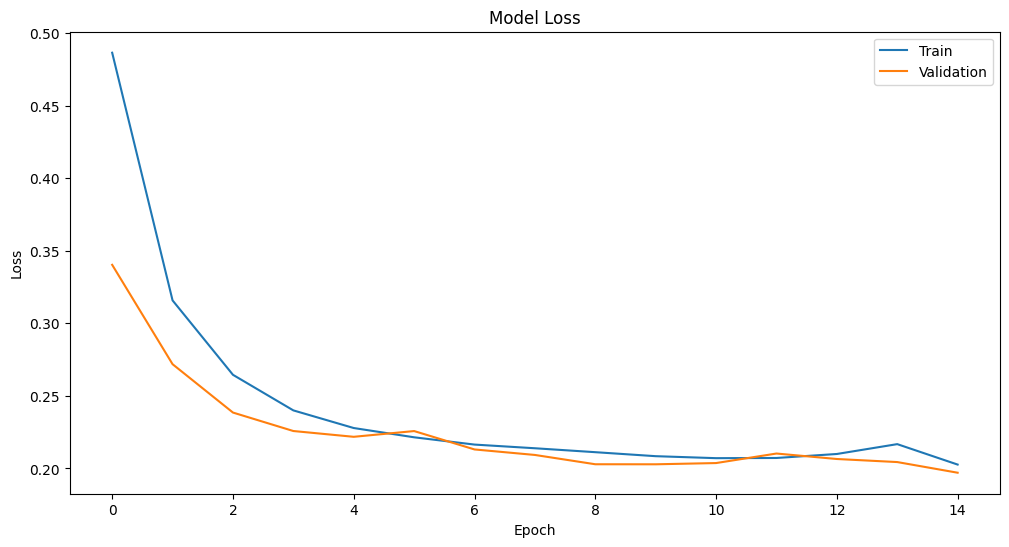

In [75]:
plt.figure(figsize=(12,6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train','Validation'],loc='upper right')
plt.show()

### 2. Accuracy

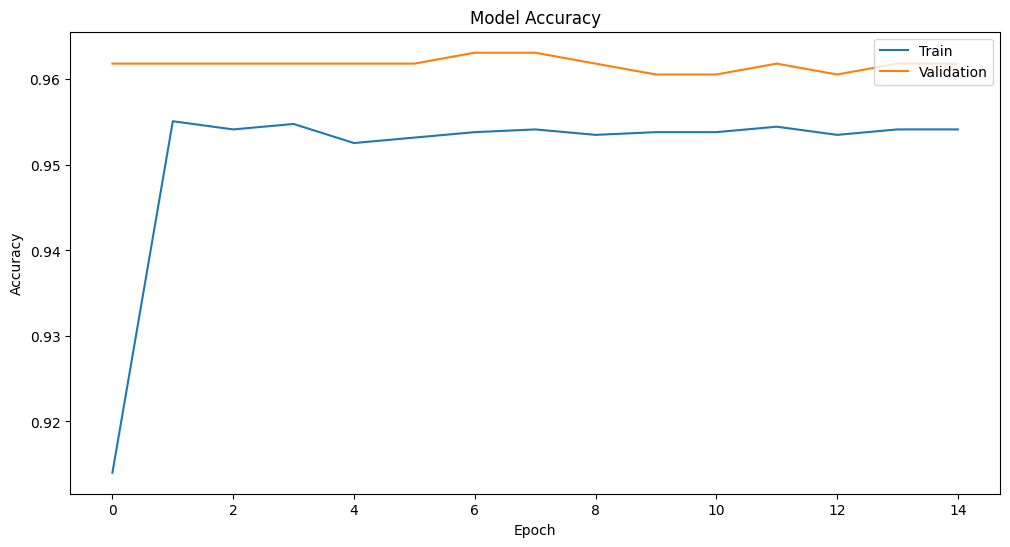

In [76]:
plt.figure(figsize=(12,6))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'],loc='upper right')
plt.show()

# Evaluation Of Loss & Accuracy On Test Data

In [77]:
loss,accuracy=model.evaluate(x_test,y_test)
print(f"Test Loss:{loss}")
print(f"Test accuracy:{accuracy}")

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9706 - loss: 0.1507
Test Loss:0.18599958717823029
Test accuracy:0.9613034725189209
